# Advanced Statistics 

In [2]:
import scipy.stats as stats

In [12]:
# Head pressure when breaking Mid size car
midsize=[646,638,444,576,681,645,547,405,447,681,481,491,523,634,529,637,475,547,456,637]
# Head pressure when breaking SUV car
suv=[669,682,444,527,697,574,457,614,560,506,403,621,553,695,620,459,691,571,436,607]

Significance Level (α):
The significance level, denoted as α, is the probability of rejecting the null hypothesis when it is actually true (Type I error).

Commonly used values are 0.05 (5%)

H0- Mean Pressure of Mid Size Car = Mean Pressure of SUV

Ha- Mean Pressure of Mid Size Care is not equal to Mean Pressure of SUV

Threshold for Rejecting the Null Hypothesis

A commonly used threshold is 0.05 (5%).

If p-value ≤ 0.05, reject the null hypothesis(h0).

If p-value > 0.05, fail to reject the null hypothesis.  which means we need to accept the null hypothesis

In [9]:
t_stat,p_value = stats.ttest_ind(a,b,equal_var=False)

In [10]:
t_stat,p_value

(np.float64(-0.4586664753453947), np.float64(0.6490976800135744))

In [11]:
Pvalue > .05 Means we can not reject H0- Mean Pressure of Mid Size Car = Mean Pressure of SUV

SyntaxError: invalid syntax (477853773.py, line 1)

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ----------------------------
# 1. Create a large population
# ----------------------------
np.random.seed(42)

population_size = 1_000_000
population = np.random.exponential(scale=5, size=population_size)

true_mean = np.mean(population)

print(f"True Population Mean: {true_mean:.3f}")



True Population Mean: 5.006



Rejection Rate: 0.050


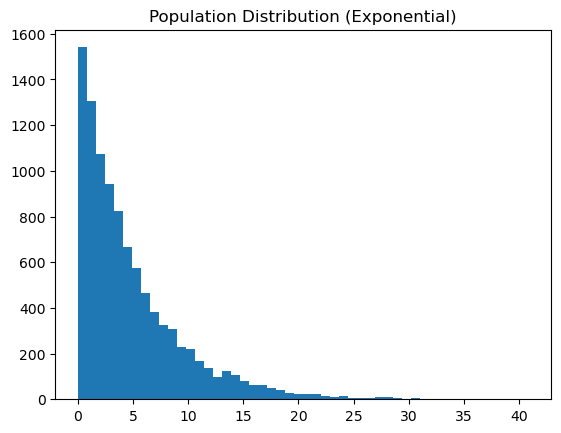

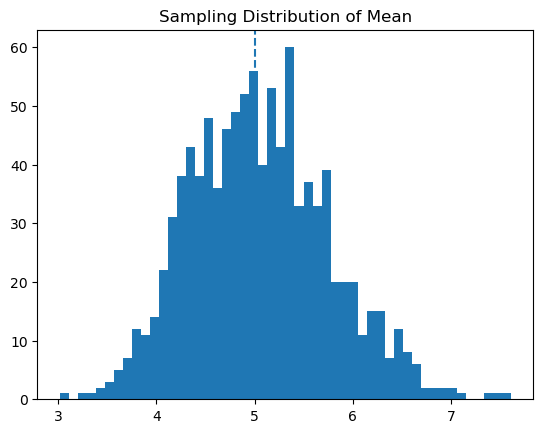

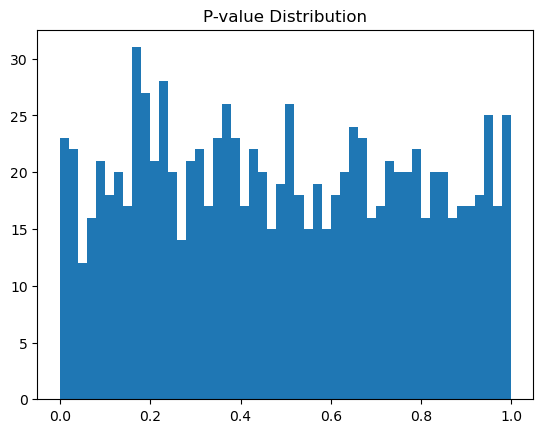

In [20]:
# ----------------------------
# 2. Hypothesis setup
# ----------------------------
H0_mean = 5   # null hypothesis mean
sample_size = 50
num_simulations = 1000
alpha = 0.05

rejections = 0
sample_means = []
p_values = []
t_stat_values = []
# ----------------------------
# 3. Run simulations
# ----------------------------
for _ in range(num_simulations):
    sample = np.random.choice(population, size=sample_size)
    
    sample_mean = np.mean(sample)
    sample_std = np.std(sample, ddof=1)
    
    # One-sample t-test
    t_stat = (sample_mean - H0_mean) / (sample_std / np.sqrt(sample_size))
    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=sample_size - 1))
    
    sample_means.append(sample_mean)
    p_values.append(p_value)
    t_stat_values.append(t_stat)
    
    if p_value < alpha:
        rejections += 1

# ----------------------------
# 4. Results
# ----------------------------
print(f"\nRejection Rate: {rejections / num_simulations:.3f}")
#print( "Means : " , sample_means)

# ----------------------------
# 5. Visualizations
# ----------------------------

# Population distribution
plt.hist(population[:10000], bins=50)
plt.title("Population Distribution (Exponential)")
plt.show()

# Sampling distribution
plt.hist(sample_means, bins=50)
plt.title("Sampling Distribution of Mean")
plt.axvline(H0_mean, linestyle='--')
plt.show()

# P-value distribution
plt.hist(p_values, bins=50)
plt.title("P-value Distribution")
plt.show()

In [13]:
t_stat, p_value = stats.ttest_rel(
    midsize,
    suv,
    alternative='less'
)

print(t_stat,p_value)

-0.5554086404634704 0.2925480400270893


In [14]:
import numpy as np
from scipy import stats
# Data
np.random.seed(50)
tradition_scores = np.random.normal(loc=70, scale=10, size=40)
new_method_scores = np.random.normal(loc=75, scale=10, size=40)
alpha = 0.05
# ---------- Case 1: Check if NEW method is better ----------
print("---- Testing if NEW method is better (trad < new) ----")
t_stat, p_value = stats.ttest_rel(
    tradition_scores,
    new_method_scores,
    alternative='less'
)
print("TStat:", t_stat, "Pvalue:", p_value)
if p_value < alpha:
    print("Reject H0 → New teaching method improved the marks\n")
else:
    print("Fail to reject H0 → No strong evidence that new method improved marks\n")

# ---------- Case 2: Check if TRADITIONAL method is better ----------
print("---- Testing if TRADITIONAL method is better (trad > new) ----")
t_stat, p_value = stats.ttest_rel(
    tradition_scores,
    new_method_scores,
    alternative='greater'
)
print("TStat:", t_stat, "Pvalue:", p_value)
if p_value < alpha:
    print("Reject H0 → Traditional method performs better\n")
else:
    print("Fail to reject H0 → No strong evidence that traditional method is better\n")

---- Testing if NEW method is better (trad < new) ----
TStat: -2.0919438235788252 Pvalue: 0.021501447957117337
Reject H0 → New teaching method improved the marks

---- Testing if TRADITIONAL method is better (trad > new) ----
TStat: -2.0919438235788252 Pvalue: 0.9784985520428826
Fail to reject H0 → No strong evidence that traditional method is better



True Mean: 5.01
Biased Pool Mean: 1.74

Rejection Rate (Proper Sampling): 0.066
Rejection Rate (Biased Sampling): 1.000


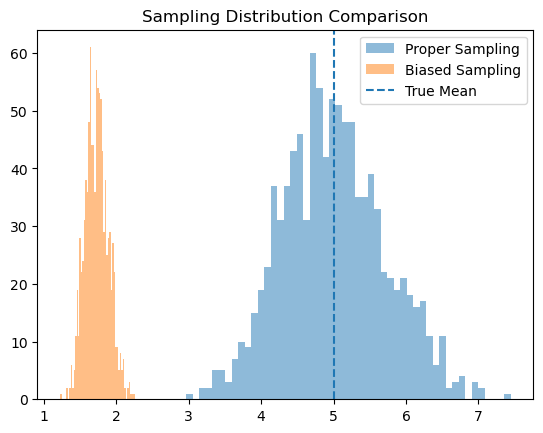

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

# ----------------------------
# 1. True population
# ----------------------------
population = np.random.exponential(scale=5, size=1_000_000)
true_mean = np.mean(population)

# ----------------------------
# 2. Create a biased "sampling pool"
# (e.g., only smaller values)
# ----------------------------
biased_pool = population[population < 4]  # truncate right tail

print(f"True Mean: {true_mean:.2f}")
print(f"Biased Pool Mean: {np.mean(biased_pool):.2f}")

# ----------------------------
# 3. Hypothesis setup
# ----------------------------
H0_mean = true_mean
sample_size = 50
num_simulations = 1000
alpha = 0.05

def run_experiment(source_data):
    rejections = 0
    sample_means = []
    
    for _ in range(num_simulations):
        sample = np.random.choice(source_data, size=sample_size)
        
        sample_mean = np.mean(sample)
        sample_std = np.std(sample, ddof=1)
        
        t_stat = (sample_mean - H0_mean) / (sample_std / np.sqrt(sample_size))
        p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=sample_size - 1))
        
        sample_means.append(sample_mean)
        
        if p_value < alpha:
            rejections += 1
            
    return rejections / num_simulations, sample_means

# ----------------------------
# 4. Run both cases
# ----------------------------
proper_rate, proper_means = run_experiment(population)
biased_rate, biased_means = run_experiment(biased_pool)

print(f"\nRejection Rate (Proper Sampling): {proper_rate:.3f}")
print(f"Rejection Rate (Biased Sampling): {biased_rate:.3f}")

# ----------------------------
# 5. Visualization
# ----------------------------

plt.hist(proper_means, bins=50, alpha=0.5, label="Proper Sampling")
plt.hist(biased_means, bins=50, alpha=0.5, label="Biased Sampling")
plt.axvline(H0_mean, linestyle='--', label="True Mean")
plt.legend()
plt.title("Sampling Distribution Comparison")
plt.show()

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import ipywidgets as widgets
from IPython.display import display

np.random.seed(42)

# Large non-normal population
population = np.random.exponential(scale=5, size=1_000_000)
true_mean = np.mean(population)

# Simulation parameters
sample_size = 50
num_simulations = 500
alpha = 0.05

def simulate(bias_strength):
    """
    bias_strength: 0 (no bias) to 1 (strong bias)
    """
    
    # Create biased sampling pool
    if bias_strength == 0:
        sampling_pool = population
    else:
        # progressively truncate upper tail
        cutoff = np.percentile(population, 100 * (1 - bias_strength))
        sampling_pool = population[population < cutoff]
    
    sample_means = []
    rejections = 0
    
    for _ in range(num_simulations):
        sample = np.random.choice(sampling_pool, size=sample_size)
        
        sample_mean = np.mean(sample)
        sample_std = np.std(sample, ddof=1)
        
        t_stat = (sample_mean - true_mean) / (sample_std / np.sqrt(sample_size))
        p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=sample_size - 1))
        
        sample_means.append(sample_mean)
        
        if p_value < alpha:
            rejections += 1
    
    rejection_rate = rejections / num_simulations
    
    # Plot
    plt.figure()
    plt.hist(sample_means, bins=40)
    plt.axvline(true_mean, linestyle='--')
    plt.title(f"Bias Strength: {bias_strength:.2f} | Rejection Rate: {rejection_rate:.3f}")
    plt.xlabel("Sample Mean")
    plt.ylabel("Frequency")
    plt.show()

# Slider
slider = widgets.FloatSlider(
    value=0,
    min=0,
    max=0.9,
    step=0.1,
    description='Bias:',
    continuous_update=False
)

widgets.interactive(simulate, bias_strength=slider)

interactive(children=(FloatSlider(value=0.0, continuous_update=False, description='Bias:', max=0.9), Output())…

In [23]:
from statsmodels.stats.weightstats import ztest
z_stat, p_value= ztest( tradition_scores,new_method_scores, alternative='smaller')
print("ZStat", z_stat, "Pvalue", p_value)

ZStat -1.9050829077885478 Pvalue 0.028384647418519187


In [24]:
z_stat, p_value= ztest( tradition_scores,new_method_scores, alternative='larger')# going in opposite direction 
print("ZStat", z_stat, "Pvalue", p_value)

ZStat -1.9050829077885478 Pvalue 0.9716153525814808


here we were saying as null hypothesis neww scores are larger than traditional and pvalue came as 0.97
which means highly agreed condition condition so without any further discussion it is finalized that yes new score are better

---

In [1]:
# Chi Square Test
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency
np.random.seed(42)
# Simulate 100 people
n = 100
# Random gender
gender = np.random.choice(['Male', 'Female'], size=n)
# Product preference (biased for learning)
product = []
for g in gender:
    if g == 'Male':
        product.append(np.random.choice(['A', 'B'], p=[0.7, 0.3]))
    else:
        product.append(np.random.choice(['A', 'B'], p=[0.4, 0.6]))
# Create dataframe
df = pd.DataFrame({
    'Gender': gender,
    'Product': product
})
df.head()
# Creating contingency Table
table = pd.crosstab(df['Gender'], df['Product'])
table
chi2, p, dof, expected = chi2_contingency(table)
print('Chi-square value:', chi2)
print('P-value:', p)
print('Degrees of freedom:', dof)
print('Expected values:\n', expected)
# Interpretation 
if p < 0.05:
    print('Reject H0 → Gender and Product are related')
else:
    print('Fail to reject H0 → No relationship')

Chi-square value: 6.2224658119880925
P-value: 0.012613931711249226
Degrees of freedom: 1
Expected values:
 [[29.68 26.32]
 [23.32 20.68]]
Reject H0 → Gender and Product are related


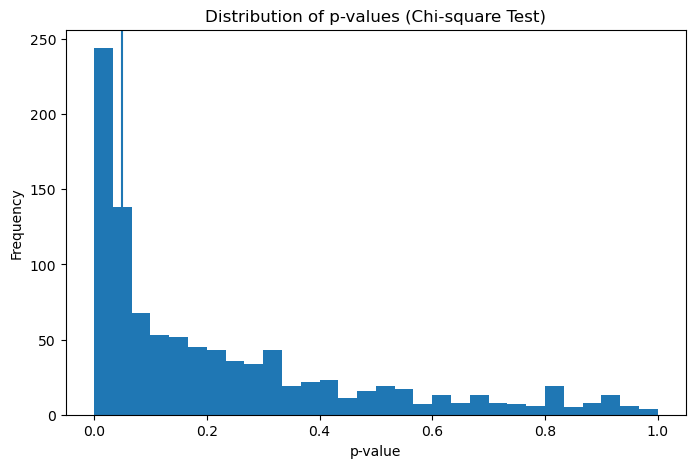

Proportion of significant results: 0.322


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Set seed for reproducibility
np.random.seed(42)

# ---- Step 1: Create large population ----
population_size = 100000

# Gender: 0 = Male, 1 = Female
genders = np.random.choice(['Male', 'Female'], size=population_size)

# Product preference depends on gender
products = []
for g in genders:
    if g == 'Male':
        products.append(np.random.choice(['A', 'B', 'C'], p=[0.5, 0.3, 0.2]))
    else:
        products.append(np.random.choice(['A', 'B', 'C'], p=[0.2, 0.5, 0.3]))

population = pd.DataFrame({
    'Gender': genders,
    'Product': products
})

# ---- Step 2: Simulation ----
num_simulations = 1000
sample_size = 30

p_values = []

for _ in range(num_simulations):
    sample = population.sample(sample_size)

    # Contingency table
    contingency = pd.crosstab(sample['Gender'], sample['Product'])

    # Chi-square test
    chi2, p, dof, expected = chi2_contingency(contingency)
    
    p_values.append(p)

# ---- Step 3: Visualization ----
plt.figure(figsize=(8, 5))
plt.hist(p_values, bins=30)
plt.axvline(0.05)  # significance level
plt.title("Distribution of p-values (Chi-square Test)")
plt.xlabel("p-value")
plt.ylabel("Frequency")
plt.show()

# ---- Step 4: Proportion of significant tests ----
significant = np.mean(np.array(p_values) < 0.05)
print(f"Proportion of significant results: {significant:.3f}")

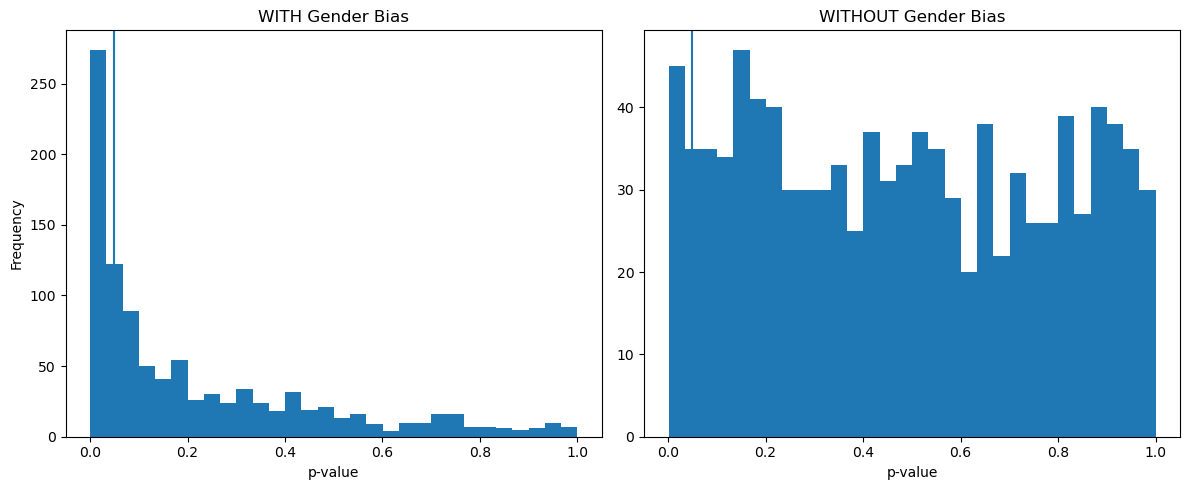

Significant (with bias): 0.336
Significant (no bias): 0.060


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

np.random.seed(42)

# -------------------------------
# Step 1: Create populations
# -------------------------------
population_size = 100000

# Gender distribution
genders = np.random.choice(['Male', 'Female'], size=population_size)

# ---- Case 1: WITH gender bias ----
products_biased = []
for g in genders:
    if g == 'Male':
        products_biased.append(np.random.choice(['A', 'B', 'C'], p=[0.5, 0.3, 0.2]))
    else:
        products_biased.append(np.random.choice(['A', 'B', 'C'], p=[0.2, 0.5, 0.3]))

population_biased = pd.DataFrame({
    'Gender': genders,
    'Product': products_biased
})

# ---- Case 2: WITHOUT gender bias ----
products_unbiased = np.random.choice(['A', 'B', 'C'], size=population_size, p=[0.33, 0.33, 0.34])

population_unbiased = pd.DataFrame({
    'Gender': genders,
    'Product': products_unbiased
})

# -------------------------------
# Step 2: Simulation function
# -------------------------------
def run_simulation(population, n_sim=1000, sample_size=30):
    p_vals = []
    
    for _ in range(n_sim):
        sample = population.sample(sample_size)

        contingency = pd.crosstab(sample['Gender'], sample['Product'])

        chi2, p, dof, expected = chi2_contingency(contingency)
        p_vals.append(p)
    
    return np.array(p_vals)

# Run simulations
p_biased = run_simulation(population_biased)
p_unbiased = run_simulation(population_unbiased)

# -------------------------------
# Step 3: Visualization
# -------------------------------
plt.figure(figsize=(12, 5))

# Biased case
plt.subplot(1, 2, 1)
plt.hist(p_biased, bins=30)
plt.axvline(0.05)
plt.title("WITH Gender Bias")
plt.xlabel("p-value")
plt.ylabel("Frequency")

# Unbiased case
plt.subplot(1, 2, 2)
plt.hist(p_unbiased, bins=30)
plt.axvline(0.05)
plt.title("WITHOUT Gender Bias")
plt.xlabel("p-value")

plt.tight_layout()
plt.show()

# -------------------------------
# Step 4: Compare significance rates
# -------------------------------
sig_biased = np.mean(p_biased < 0.05)
sig_unbiased = np.mean(p_unbiased < 0.05)

print(f"Significant (with bias): {sig_biased:.3f}")
print(f"Significant (no bias): {sig_unbiased:.3f}")

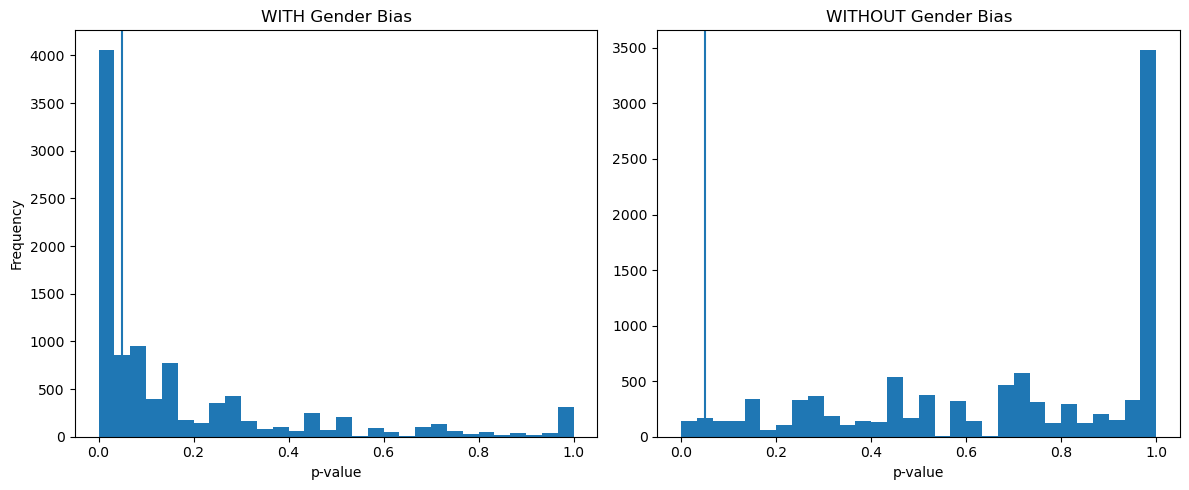

Significant (with bias): 0.445
Significant (no bias): 0.020


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
np.random.seed(42)
# -------------------------------
# Step 1: Create populations
# -------------------------------
population_size = 1000000
# Gender distribution
genders = np.random.choice(['Male', 'Female'], size=population_size)
# ---- Case 1: WITH gender bias ----
products_biased = []
for g in genders:
    if g == 'Male':
        products_biased.append(np.random.choice(['A', 'B'], p=[0.7, 0.3]))
    else:
        products_biased.append(np.random.choice(['A', 'B'], p=[0.3, 0.7]))
population_biased = pd.DataFrame({
    'Gender': genders,
    'Product': products_biased
})
# ---- Case 2: WITHOUT gender bias ----
products_unbiased = np.random.choice(['A', 'B'], size=population_size)
population_unbiased = pd.DataFrame({
    'Gender': genders,
    'Product': products_unbiased
})
# -------------------------------
# Step 2: Simulation function
# -------------------------------
def run_simulation(population, n_sim=10000, sample_size=30):
    p_vals = []
    
    for _ in range(n_sim):
        sample = population.sample(sample_size)
        contingency = pd.crosstab(sample['Gender'], sample['Product'])
        chi2, p, dof, expected = chi2_contingency(contingency)
        p_vals.append(p)
    
    return np.array(p_vals)
# Run simulations
p_biased = run_simulation(population_biased)
p_unbiased = run_simulation(population_unbiased)
# -------------------------------
# Step 3: Visualization
# -------------------------------
plt.figure(figsize=(12, 5))
# Biased case
plt.subplot(1, 2, 1)
plt.hist(p_biased, bins=30)
plt.axvline(0.05)
plt.title("WITH Gender Bias")
plt.xlabel("p-value")
plt.ylabel("Frequency")
# Unbiased case
plt.subplot(1, 2, 2)
plt.hist(p_unbiased, bins=30)
plt.axvline(0.05)
plt.title("WITHOUT Gender Bias")
plt.xlabel("p-value")
plt.tight_layout()
plt.show()
# -------------------------------
# Step 4: Compare significance rates
# -------------------------------
sig_biased = np.mean(p_biased < 0.05)
sig_unbiased = np.mean(p_unbiased < 0.05)
print(f"Significant (with bias): {sig_biased:.3f}")
print(f"Significant (no bias): {sig_unbiased:.3f}")

[1.00981853e-18 2.38776034e-19 8.79690634e-22 7.39352466e-19
 4.07354901e-21 2.37467504e-17 2.46465937e-18 2.61679160e-19
 7.27610452e-20 3.66320418e-23]


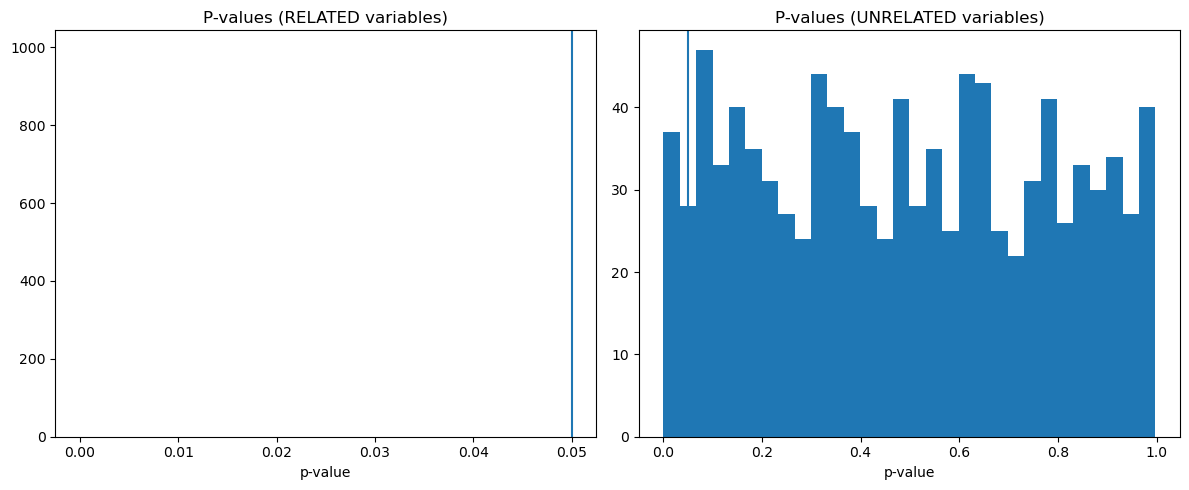

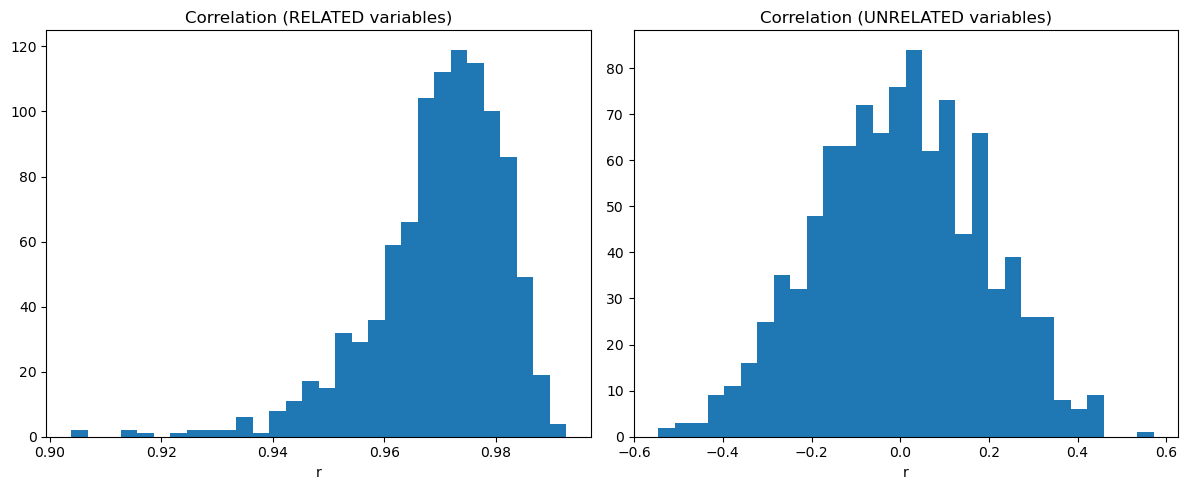

=== SUMMARY ===
Mean correlation (related): 0.970
Mean correlation (unrelated): -0.001
Significant p-values (related): 1.000
Significant p-values (unrelated): 0.048


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

np.random.seed(42)

# -----------------------------
# Parameters
# -----------------------------
n_sim = 1000
sample_size = 30

pvals_related = []
corrs_related = []

pvals_unrelated = []
corrs_unrelated = []

# -----------------------------
# Simulation loop
# -----------------------------
for _ in range(n_sim):
    
    # -------- Case 1: RELATED --------
    X1 = np.random.normal(0, 1, sample_size)
    noise = np.random.normal(0, 0.5, sample_size)
    Y1 = 2 * X1 + noise   # strong linear relationship
    
    r1, p1 = pearsonr(X1, Y1)
    
    corrs_related.append(r1)
    pvals_related.append(p1)
    
    
    # -------- Case 2: UNRELATED --------
    X2 = np.random.normal(0, 1, sample_size)
    Y2 = np.random.normal(0, 1, sample_size)  # independent
    
    r2, p2 = pearsonr(X2, Y2)
    
    corrs_unrelated.append(r2)
    pvals_unrelated.append(p2)

# -----------------------------
# Convert to arrays
# -----------------------------
pvals_related = np.array(pvals_related)
pvals_unrelated = np.array(pvals_unrelated)

corrs_related = np.array(corrs_related)
corrs_unrelated = np.array(corrs_unrelated)

# -----------------------------
# Plot P-values
# -----------------------------
plt.figure(figsize=(12,5))

print(pvals_related[:10])

plt.subplot(1,2,1)
plt.hist(pvals_related, bins=30)
plt.axvline(0.05)
plt.title("P-values (RELATED variables)")
plt.xlabel("p-value")

plt.subplot(1,2,2)
plt.hist(pvals_unrelated, bins=30)
plt.axvline(0.05)
plt.title("P-values (UNRELATED variables)")
plt.xlabel("p-value")

plt.tight_layout()
plt.show()

# -----------------------------
# Plot Correlations
# -----------------------------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(corrs_related, bins=30)
plt.title("Correlation (RELATED variables)")
plt.xlabel("r")

plt.subplot(1,2,2)
plt.hist(corrs_unrelated, bins=30)
plt.title("Correlation (UNRELATED variables)")
plt.xlabel("r")

plt.tight_layout()
plt.show()

# -----------------------------
# Summary stats
# -----------------------------
print("=== SUMMARY ===")
print(f"Mean correlation (related): {np.mean(corrs_related):.3f}")
print(f"Mean correlation (unrelated): {np.mean(corrs_unrelated):.3f}")

print(f"Significant p-values (related): {np.mean(pvals_related < 0.05):.3f}")
print(f"Significant p-values (unrelated): {np.mean(pvals_unrelated < 0.05):.3f}")

In [9]:
import numpy as np
from scipy.stats import pearsonr, spearmanr
x = np.array([10, 20, 30, 40, 50])
y = np.array([15, 25, 35, 45, 60])
corr_matrix = np.corrcoef(x, y)
print(corr_matrix)
print("Pearson (NumPy):", corr_matrix[0,1])
r, p = pearsonr(x, y)
print("Pearson Correlation:", r)
print("P-value:", p)
# here it is  p value is 0.0003 which is <0.05 so we reject null hypothesis -- accept alternate-- there is relatioship

[[1.         0.99589321]
 [0.99589321 1.        ]]
Pearson (NumPy): 0.995893206467704
Pearson Correlation: 0.9958932064677037
P-value: 0.00031573334241720663
